In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

import SparseFit as sf
PATH = sf.path.PATH

Bagpipes: Latex distribution not found, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


In [2]:
name = "NGC0628"

path_img    = f"{PATH}/data/{name}/image/"
path_masked = f"{PATH}/data/{name}/masked/"
path_match  = f"{PATH}/data/{name}/matched/"
path_flux   = f'{PATH}/data/{name}/flux/'

fluxmap = path_match + f"fluxmap.fits"
fluxmap_lowres = path_match + f"fluxmap_lowres.fits"
pixbin_map = path_match + f"pixbin_fluxmap.fits"

sci_img, var_img = sf.utils.utils_file.load_filenames(name)
sci_match, var_match = sf.utils.utils_file.load_filenames(name, prefix="match_")
filters = sf.utils.utils_filter.load_gal_filters(name)

TODO here:  
- background subtraction
- image masking

## Image cropping

In [ ]:
sf.image_process.image_crop.crop(img_path=path_img,
                                 sci_img=sci_img, var_img=var_img,
                                 filters=filters, galaxy=name)

## Image matching

In [ ]:
ref_band = 'wise_w4'
filters_high_flag = sf.image_process.image_psf.match_image(img_path=path_masked, 
                                    sci_img=sci_img, var_img=var_img, 
                                    filters=filters, flux_or_sb='flux',
                                    ref_band=ref_band, out_path=path_match)

In [ ]:
region = sf.binning.pix_cube.galaxy_region(path_match, sci_match, var_match, 
                                           filter_ids=[0,1], 
                                           contrast=1, thresh=3, dilate_iter=10)

In [ ]:
filters_high = [f for i,f in enumerate(filters) if filters_high_flag[i]]
filters_low  = [f for i,f in enumerate(filters) if not filters_high_flag[i]]
filters_low.insert(0, ref_band)

sci_highres = sf.utils.utils_file.select_dict(sci_match, filters_high)
var_highres = sf.utils.utils_file.select_dict(var_match, filters_high)
sci_lowres = sf.utils.utils_file.select_dict(sci_match, filters_low)
var_lowres = sf.utils.utils_file.select_dict(var_match, filters_low)

sf.binning.pix_cube.flux_map(img_path=path_match, 
                             sci_img=sci_highres, var_img=var_highres, 
                             filters=filters_high, gal_region=region,
                             dp_unit=True,
                             gname=name)

sf.binning.pix_cube.flux_map(img_path=path_match, 
                             sci_img=sci_lowres, var_img=var_lowres, 
                             filters=filters_low, gal_region=region,
                             dp_unit=True,
                             gname=name,
                             name_out_fits="fluxmap_lowres.fits")

In [ ]:
# flux_map = fits.open(fluxmap)
sf.binning.pix_cube.plot_flux_maps('./data/NGC0628/matched/fluxmap.fits')

## Pixel binning

In [ ]:
SNR = np.zeros(len(filters_high))
SNR[[0,1,3,4,6]] = 50  # GALEX + SDSS

bin_args = {"ref_band": 3,          # SDSS g-band
            "Dmin_bin": 3,
            "SNR": SNR,     
            "redc_chi2_limit": 10,  # SED similarity limit
            "r_growth": 3,          # equal to Dmin_bin
            "dr_growth": 3,        
            "grow_percentile": 50,  # brightest pixels kept
            "out_path": pixbin_map}

sf.binning.pix_binning.pixel_binning(fluxmap, **bin_args)

In [ ]:
sf.binning.pix_binning.plot_binning(pixbin_map, show_idx=False, 
                                    xlim=(80, 250), ylim=(80, 250), vmin=0)

In [ ]:
# bootstrapping is slow ...
img_paths = [path_match + 'match_' + sci_img[f] for f in filters]

bflux, e_bflux = sf.binning.pix_binning.get_bin_flux(
    pixbin_path=pixbin_map, 
    fluxmap_path=fluxmap, 
    img_paths=img_paths)

In [ ]:
sf.utils.utils_phot.save_flux(bflux, e_bflux, filters_high,
                              out_path=path_flux,
                              prefix='highres_')

### estimate gas-phase metallicity

In [ ]:
sf.binning.pix_metal.estimate_metallicity(
    pixbin_path=pixbin_map,
    ref_img_path=path_match + 'match_' + sci_img[ref_band],
    logMstar=10.24, PA=19, incl=6.5, R50=101.2, # from z0MGS (J. Sun et al. 2025)
    nebular_metal_table=path_flux + 'nebular_metallicity.npy')

sf.binning.pix_metal.plot_metal_map(path_flux + 'nebular_metallicity.npy', pixbin_map,
                                    cmap='turbo', vmin=0.3)

## Run BAGPIPES (high-res run)

BAGPIPES is run on HPC clusters (see demo_hpc.py), but can be teseted here:

In [12]:
sf.fitting.fit_bagpipes.run(ID=35,
                        flux_table=f"{path_flux}/highres_flux_table.fits",
                        nebular_metal=f"{path_flux}/nebular_metallicity.npy",
                        pool=4, run=f"{name}_highres")


Bagpipes: fitting object 35

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Bagpipes: lnlike was nan, replaced with zero probability.000 | 0     | N/A      
Bagpipes: lnlike was nan, replaced with zero probability.
Bagpipes: lnlike was nan, replaced with zero probability.
Bagpipes: lnlike was nan, replaced with zero probability.
Bagpipes: lnlike was nan, replaced with zero probability.
Bagpipes: lnlike was nan, replaced with zero probability.
Bagpipes: lnlike was nan, replaced with zero probability.
Bagpipes: lnlike was nan, replaced with zero probability.Bagpipes: lnlike was nan, replaced with zero probability.

Bagpipes: lnlike was nan, replaced with zero probability.
Bagpipes: lnlike was nan, replaced with zero probability.
Bagpipes: lnlike was nan, replaced with zero probability.
Bagpipes: lnlike was nan, replaced with zero probability.Bagpipes: lnlike was na

## Add low-res constraints

In [ ]:
# loading a large amount of SED results can be slow ...
sf.fitting.fit_lowres.predict_flux_table(f"{path_flux}/highres_flux_table.fits",
                        filters=filters, 
                        galaxy=name, run='_highres',
                        out_path=path_flux)

In [ ]:
sf.fitting.predict_flux_map(f"{path_flux}/pred_flux_table.fits",
                            pixbin_map=pixbin_map,
                            out_path=path_flux)

### update low-res fluxes

In [ ]:
sf.fitting.fit_lowres.new_flux_table(pred_map_path=f"{path_flux}/pred_map.npz",
                   fluxmap_lowres=fluxmap_lowres,
                   pixbin_map=pixbin_map,
                   pred_flux_path=f"{path_flux}/pred_flux_table.fits",
                   out_file=f"{path_flux}/flux_table.fits")

### check predicted maps and residuals

In [ ]:
from astropy.convolution import convolve_fft

pred_map = np.load(f"{path_flux}/pred_map.npz")
pred_map_conv = np.load(f"{path_flux}/pred_map_conv.npz")
pred_map_upd = np.load(f"{path_flux}/pred_map_updated.npz")
temp = fits.open(fluxmap_lowres)[0].data[1:] / 1e17

for i, f in enumerate(filters_low[1:]):
    vmax = np.nanmax(temp[i])
    _args = {'cmap': 'turbo', 'vmin': 0, 'vmax': vmax}
    plt.figure(figsize=(15,2.5))
    plt.subplot(161)
    plt.imshow(temp[i], **_args)
    plt.title(f"{f} observed")
    plt.subplot(162)
    plt.imshow(pred_map[f][0], **_args)
    plt.title(f"predicted")
    plt.subplot(163)
    plt.imshow(pred_map_conv[f][0], **_args)
    plt.title(f"predicted (conv)")
    plt.subplot(164)
    plt.imshow(pred_map_upd[f][0], **_args)
    plt.title(f"predicted (updated)")
    plt.subplot(165)
    kernel = sf.image_process.image_psf.load_kernel('wise_w4', f, pix_scale=4)
    conv_upd = convolve_fft(pred_map_upd[f][0], kernel)
    plt.imshow(conv_upd, **_args)
    plt.title(f"predicted (updated, conv)")
    plt.subplot(166)
    plt.imshow((temp[i]-conv_upd) / pred_map_upd[f][1],
                cmap='seismic', vmin=-3, vmax=3)
    plt.title("residual")

    plt.tight_layout()
    plt.show()

## Run BAGPIPES (full)

It's better to run on an HPC cluster (see demo_hpc.py), but it can be teseted here:

In [ ]:
sf.fitting.fit_bagpipes.run(ID=0,
                        flux_table=f"{path_flux}/flux_table.fits",
                        nebular_metal=f"{path_flux}/nebular_metallicity.npy",
                        pool=4, run=name)

In [24]:
_sed = sf.fitting.load_sed.BSEDresults(name=name, run='_highres', ID=35,
                                       flux_table=f"{path_flux}/highres_flux_table.fits", advanced=True)


Results loaded from pipes/posterior/NGC0628_highres/35.h5



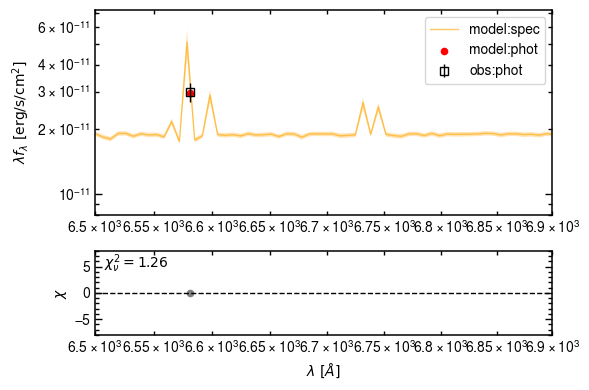

(array([[0.00229739, 0.00178323, 0.00278294],
        [0.00420534, 0.00263472, 0.00598105],
        [0.0053806 , 0.00384888, 0.00738072],
        [0.00533447, 0.0036592 , 0.00738415],
        [0.00558745, 0.00373953, 0.0081783 ],
        [0.00812573, 0.00533845, 0.01226761],
        [0.01618794, 0.01122863, 0.02231997],
        [0.02274463, 0.01566493, 0.03022283]]),
 [0, 10, 30, 100, 300, 1000, 3000, 7000, np.float64(12970.4150470028)])

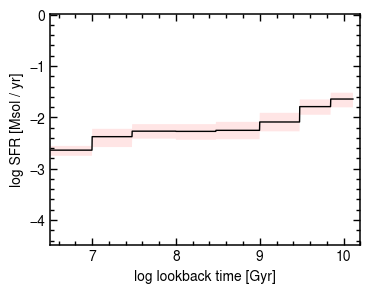

In [26]:
_sed.plot_results(plot_range='Ha', ymax=6e-11, ymin=1e-11)
_sed.Leja19_SFH(plot=True)

(0.0, 50.0)

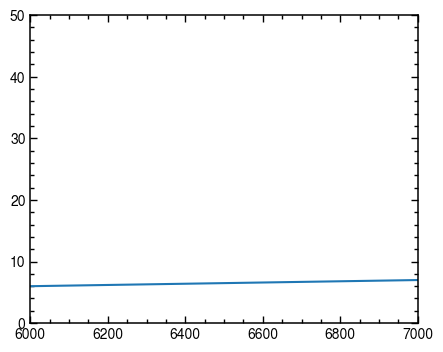

In [27]:
wave = _sed.fit.posterior.model_galaxy.wavelengths
plt.plot((wave[1:] + wave[:-1]) / 2, np.diff(wave))
plt.xlim(6000, 7000)
plt.ylim(0, 50)